# Mercor Cheating Detection
## I. Introduction
### A. Problem Description
Our goal in this challenge is to predict whether an candidate is engaging in cheating behavior during an interview. We have data that includes anonymized behavioral features, platform activity signals, and a social graph that captures relationships between users across the network.  
### B. Evaluation
Evaluations are performed using a cost-based metric that is designed to reflect real-world operational costs used in cheating detection. Our evaluation should automatically search for optimal decision thresholds that minimize total cost across the following decision regions:
1. Auto-pass (low cheating risk)
2. Manual review (medium cheating risk)
3. Auto-block (high cheating risk)  

The cost structure for this evaluation is defined as follows:
- False Negative (cheating passes through): $600
- False Positive in auto-block region: $300
- False Positive in manual review region: $150
- True Positive requiring manual review: $5
- Correct auto-pass or auto-block: $0  
The score is the negative of the minimum total cost found across all threshold cominations. Higher is better. Our model will need to make confident, correct decisions while penalizing costly operational errors.

## II. Setup
### A. Imports
We are importing standard ML workflow libraries. We'll stick to proven models for this baseline evaluation.

In [75]:
from collections import Counter
import math
from pathlib import Path 
from typing import Optional, Union

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier 
from matplotlib.axes import Axes 
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from tqdm import tqdm

### B. Configuration

In [2]:
sns.set_style("whitegrid")

class CFG:
    # Data configuration
    DATA_DIR = ("../input/mercor-cheating-detection")
    TRAIN_PATH = DATA_DIR / Path("train.csv")
    TEST_PATH = DATA_DIR / Path("test.csv")
    SOCIAL_GRAPH_PATH = DATA_DIR / Path("social_graph.csv")
    SAMPLE_SUB_PATH = DATA_DIR / Path("sample_submission.csv")

    # Hyperparameter configuration
    SEED = 15
    VALID_SIZE = 0.1

    # Determined from `feature_metadata.json`
    NUMERIC_FEATURES = [
        "feature_001", "feature_002", "feature_003", "feature_004", "feature_005",
        "feature_006", "feature_008", "feature_009", "feature_010", "feature_012",
        "feature_015", "feature_016", "feature_017", "feature_018"
    ]
    BINARY_FEATURES = [
        "feature_007", "feature_011", "feature_013", "feature_014", "high_conf_clean"
    ]
    TARGET = "is_cheating"

### C. Load and Preview Data

In [3]:
train = pd.read_csv(CFG.TRAIN_PATH)
social_graph = pd.read_csv(CFG.SOCIAL_GRAPH_PATH)
test = pd.read_csv(CFG.TEST_PATH)
sample = pd.read_csv(CFG.SAMPLE_SUB_PATH)

print("*" * 80)
print(f"Train shape: {train.shape}")
print(train.info(), "\n")
print("Percentage of misssing train values:")
print(train.isna().sum() / len(train) * 100)
print("*" * 80)
print(f"Social graph shape: {social_graph.shape}")
print(social_graph.info(), "\n")
print("Percentage of misssing social graph values:")
print(social_graph.isna().sum() / len(social_graph) * 100)
print("*" * 80)
print(f"Test shape: {test.shape}")
print(test.info(), "\n")
print("Perecentage of missing test values:")
print(test.isna().sum() / len(test) * 100)
print("*" * 80)
print(f"Sample shape: {sample.shape}")
print(sample.info(), "\n")
print("*" * 80)


********************************************************************************
Train shape: (272819, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272819 entries, 0 to 272818
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   user_hash        272819 non-null  object 
 1   feature_001      240704 non-null  float64
 2   feature_002      241114 non-null  float64
 3   feature_003      241114 non-null  float64
 4   feature_004      270420 non-null  float64
 5   feature_005      267020 non-null  float64
 6   feature_006      270605 non-null  float64
 7   feature_007      266984 non-null  float64
 8   feature_008      266723 non-null  float64
 9   feature_009      266723 non-null  float64
 10  feature_010      266723 non-null  float64
 11  feature_011      267003 non-null  float64
 12  feature_012      261527 non-null  float64
 13  feature_013      267003 non-null  float64
 14  feature_014      266939 n

In [4]:
print("Features and their unique value counts:")
print(train.nunique())

Features and their unique value counts:
user_hash          272819
feature_001             5
feature_002            10
feature_003            10
feature_004            11
feature_005            10
feature_006            11
feature_007             2
feature_008            11
feature_009            11
feature_010          8154
feature_011             2
feature_012             4
feature_013             2
feature_014             2
feature_015        155430
feature_016           177
feature_017         71025
feature_018         22638
high_conf_clean         1
is_cheating             2
dtype: int64


#### Inital Insights & Hypothesis
1. Disjoint labeling: There are 272,819 rows of data in train. `high_conf_clean` has 112,966 non-null values, and `is_cheating` has 159,853 non-null values. The sum of these non-null values equals our total rows of data.
    - *Hypothesis*: The dataset is perfectly disjoint. `NaN` in `is_cheating` likely represents the "clean" target class.
    - *Possible Actions*: We should validate this assumption immediately during target analysis. If our hypothesis is correct, we should impute missing target values with `0`. 
2. Feature groups: There are several features with the exact same number of missing values. The following "groups" have exactly the same amount of missing values, both in the train and the test sets.
    * `feature_002` and `feature_003`
    * `feature_008`, `feature_009`, and `feature_010`
    * `feature_011` and `feature_013` (`feature_007` is very close)
    - *Hypothesis*: These features are likely related or derived from the same data source.
    - *Possible Actions*: We should check the correlation of missing data in these groups. We cannot decide an imputation strategy without determining how these missing features interact with each other, and across our defined "groups".
3. "Hidden" categorical/ordinal features: The provided `feature_metadata.json` provides a high-level overview about what types of data our feature contains, specifically, "numeric" or "binary". However, after viewing the unique value counts of each feature, we can infer that some features may acutally be ordinal or nominal features.
    - *Hypothesis*: `feature_001`, `feature_002`, `feature_003`, `feature_004`, `feature_005`, `feature_006`, `feature_008`, `feature_009`, and `feature_012` are likely ordinal features or encoded nominal categories. 
    - *Possible Actions*: This will require some experimentation. It is possible that the features are already encoded well enough and we just need to deal with missing values. One-hot encoding could be useful here to create a new feature from the `NaN` values.
4. No missing values: `feature_015` and `feature_016` are the only features with no missing values.
    - *Hypothesis*: These feautures could also be highly correlated or derived from the same data source.
    - *Possible Actions*: We should check the correlation of these two features. The relatively large amount of unique values in `feature_015` might provide insight as to what `feature_016` might represent.

## III. EDA
### A. Target Feature: `is_cheating`
First we test our hypothesis on our target variable and check to see if the data is disjoint.

In [5]:
overlap = train["high_conf_clean"].notna() & train["is_cheating"].notna()
print(f"Rows with overlapping labels: {overlap.sum()}")
gaps = train["high_conf_clean"].isna() & train["is_cheating"].isna()
print(f"Rows with no labels: {gaps.sum()}")

Rows with overlapping labels: 0
Rows with no labels: 0


Our hypothesis #1 is validated; we can safely fill `Nan` values in our target variable with `0`. Let's now visualize our target imbalance. We must use a stratified split when setting aside our validation data, so that a similar target value ratio is captured is across our splits.

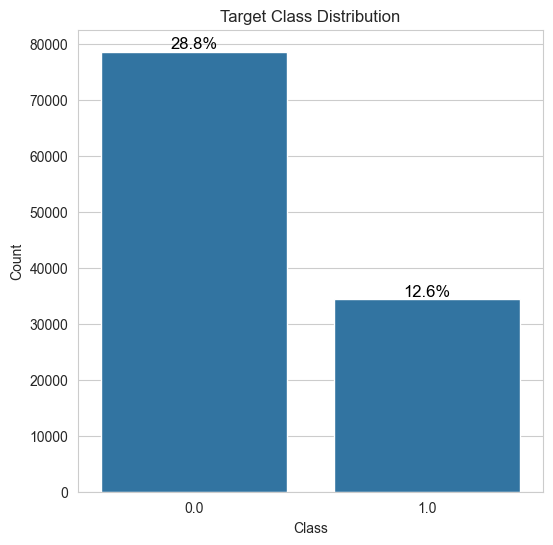

In [6]:
def plot_binary_target_counts(
    df: pd.DataFrame,
    target: str,
    title: str = "Target Class Distribution",
    xlabel: str = "Class",
    ylabel: str = "Count",
    figsize: tuple = (6, 6)
) -> None:
    """
    Plots a target class distribution countplot.
    
    Displays a seaborn count plot with optional x and y labels, and a title.
    Also displays the percentage of the sum of values for each binary class
    on the top of the bars in the countplot.
    
    Args:
        df: The Pandas DataFrame containing the features and target.
        target: The name of the target feature column.
        title: An optional title for the displayed plot.
        xlabel: An optional label for the x-axis (target values).
        ylabel: An optional label for the y-axis. Defaults to "Count".capitalize
        figsize: Confgures the size of the displayed plot. Defaults to `(6, 6)`.
    Returns:
        None
    """
    # Initialize and configure
    total = len(df)
    plt.figure(figsize=figsize)
    ax = sns.countplot(data=df, x=target)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    # Loop through each bar in the blot
    for p in ax.patches:
        height = p.get_height()
        percentage = f'{100 * height / total:.1f}%'
        ax.annotate(text=percentage,
                    xy=(p.get_x() + p.get_width() / 2., height),
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    color="black")
    plt.show()

plot_binary_target_counts(train, CFG.TARGET)

### B. Univariate Analysis
#### i. Numerical Distributions
We use histograms with a kernel density estimate overlay to check for skewness and normality. We will define a temporary list of "numeric" features that differ from the numeric features defined in the metadata and `CFG`, selecting features with relatively high value counts. We also call `describe()` to gain insight on these features values.

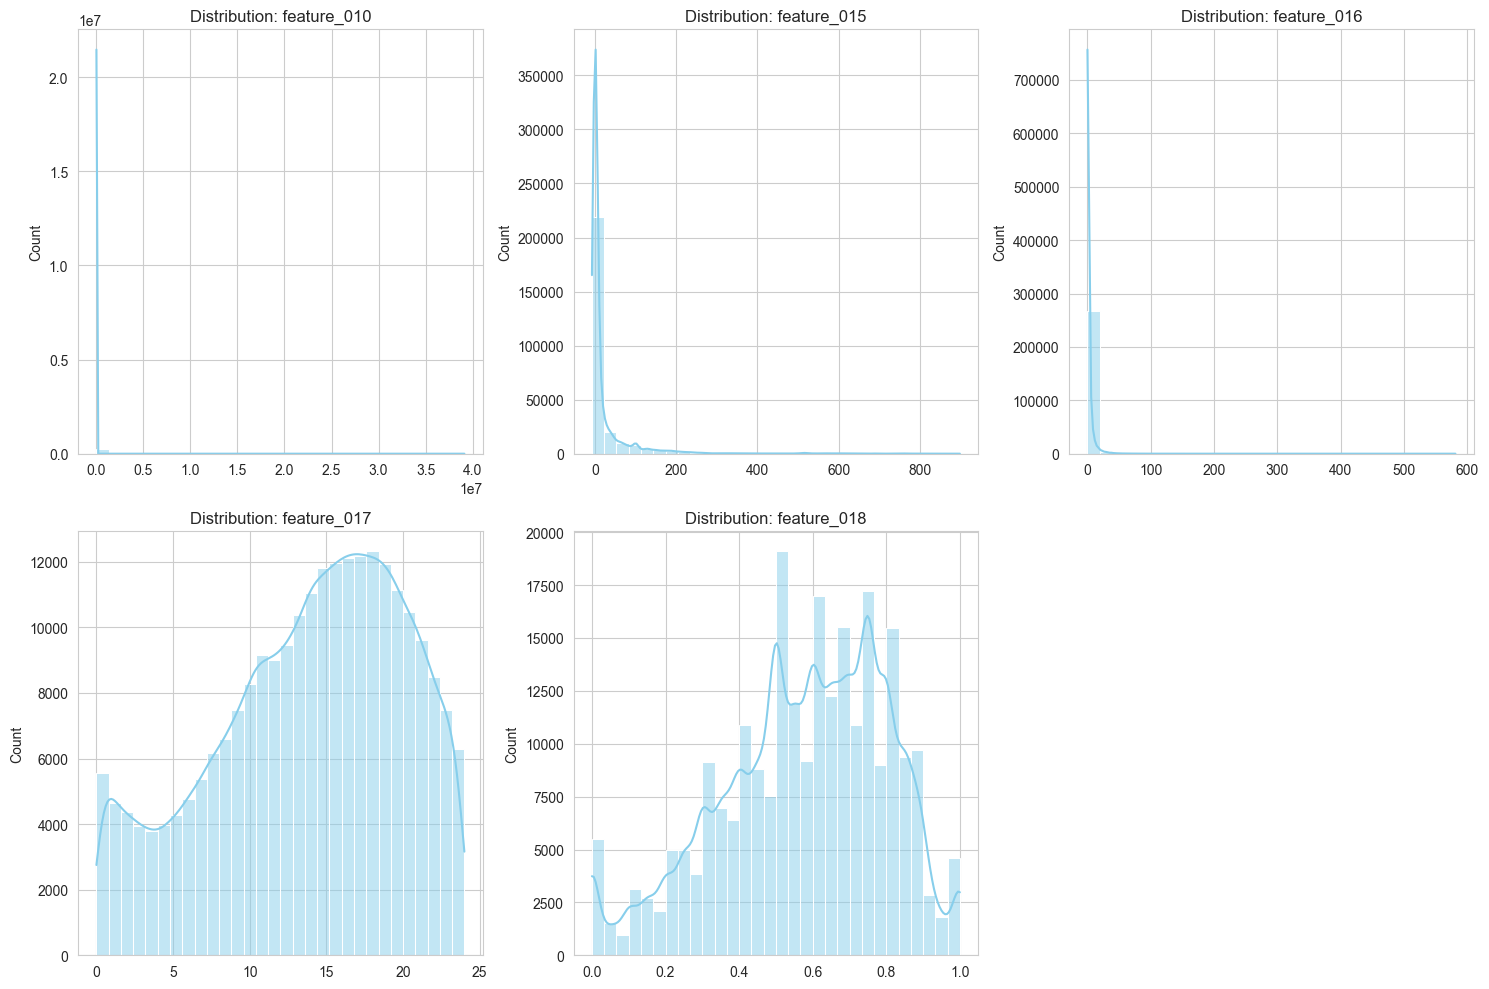

,feature_010,feature_015,feature_016,feature_017,feature_018
count,2.667230e+05,272819.000000,272819.000000,244050.000000,245184.000000
mean,8.090543e+02,25.108919,2.778905,13.805947,0.574001
std,7.735875e+04,72.878142,6.418794,6.145651,0.226960
min,0.000000e+00,-7.008252,0.000000,0.000000,0.000000
25%,0.000000e+00,0.039606,1.000000,9.616667,0.425000
50%,3.000000e+00,0.705370,1.000000,14.650000,0.600000
75%,5.050000e+02,13.845544,2.000000,18.695121,0.750000
max,3.912891e+07,897.850613,581.000000,24.000000,1.000000


In [7]:
temp_numeric_features = [
    "feature_010", "feature_015", "feature_016", "feature_017", "feature_018"
]

def plot_histograms_with_kde(
    df: pd.DataFrame,
    numeric_cols: list[str],
    n_cols: int = 3,
    bins: int = 30,
    color: str = "skyblue"
) -> None:
    """Generates a grid of histograms with Kernel Density Estimates (KDE) for specified columns.

    This function dynamically calculates the grid layout based on the number of 
    provided columns and generates a Seaborn histplot for each.

    Args:
        df (pd.DataFrame): The input DataFrame containing the data.
        numeric_cols (list[str]): A list of column names within `df` to be plotted. 
            These should correspond to numeric data types.
        n_cols (int, optional): The number of subplots to arrange horizontally 
            in one row. Defaults to 3.
        bins (int, optional): The number of bins to divide the data into for the 
            histogram. Defaults to 30.
        color (str, optional): The color of the histogram bars and KDE line. 
            Defaults to "skyblue".

    Returns:
        None: The function displays a matplotlib figure via `plt.show()` and 
        does not return a value.
    """
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols 
    plt.figure(figsize=(15, 5 * n_rows))
    for i, col in enumerate(numeric_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.histplot(data=df, x=col, kde=True, bins=bins, color=color)
        plt.title(f"Distribution: {col}")
        plt.xlabel("")
    plt.tight_layout()
    plt.show()
    
plot_histograms_with_kde(train, temp_numeric_features)

train[temp_numeric_features].describe()

#### Inital Insights & Hypothesis
1. `feature_010`, `feature_015`, and `feauture_016` are heavily skewed.
    - *Hypothesis*: There may be significatnt outliers present in these three features, or the features could be extremely noisy on tail ends.
    - *Possible Actions*: `feature_010` should be log transformed. `feature_015` will need it's negative values inspected. If there are few, drop those rows and log transform this feature. `feature_016` will also need inspected. This may need to be treated as a discrete numeric feature.
2. `feature_018` has a nice normal distribution between `0` and `1`, but the "spiky" line indicates some discrete values possibly.
    - *Hypothesis*: `feature_018` is a discrete numeric feature. 
    - *Possible Actions*: Scaling should suffice here. The data is distributed nicely. Our models will love this feature.
3. `feature_017` looks like it is likely a time-based feature, with values ranging from 0 to 24.
    - *Hypothesis*: `feature_017` likely represents "activity this hour" or something along those lines. The distribution perfectly matches human activity for most human beings at specific hours of the day.
    - *Possible Actions*: We should experiment, but it is likely we will not treat this feature as a numeric feature. `23` numerically is very different that `0` but in sense of time, they are neighbors. We should consider cyclical encoding here.

Let's run a quick check on the negative values in `feature_015`.

In [8]:
num_negatives = (train['feature_015'] < 0).sum()
pct_negatives = (num_negatives / len(train)) * 100
print(f"Number of negative values in feature_015: {num_negatives}")
print(f"Percentage of negative values: {pct_negatives:.2f}%")

Number of negative values in feature_015: 2
Percentage of negative values: 0.00%


We MUST drop the two rows in `feature_015` that have negative values. Our model cannot learn anything from only these two rows. We will not only drop these 2 rows and treat them as noise/outliers, but we will include `feature_015` in our list of features to log transform.

Let's also apply a log transform to `feature_016` and see if it will help our model(s) or not.

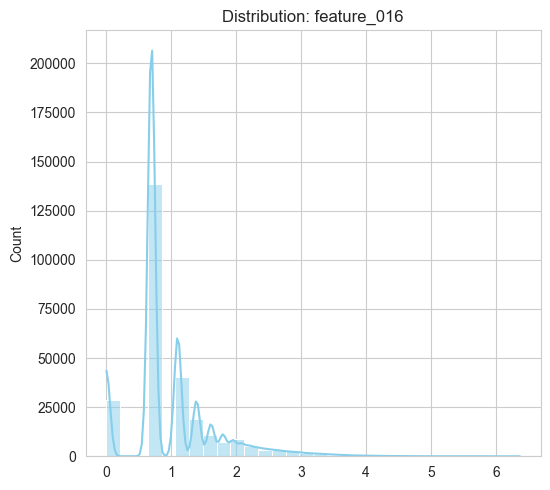

In [9]:
skewed_cols = ["feature_016"]
log_transformed_df = train[skewed_cols].apply(np.log1p)
plot_histograms_with_kde(log_transformed_df, skewed_cols)

`feature_016` should also be treated as a discrete feature. We will not apply a log transformation to this feature. Scaling should suffice.

#### ii. "Categorical" distributions
Let's use countplots to visualize our possible categorical features (or nominal encoded features). We've hypothesized that these features represent ordinal data due to there low cardinality.

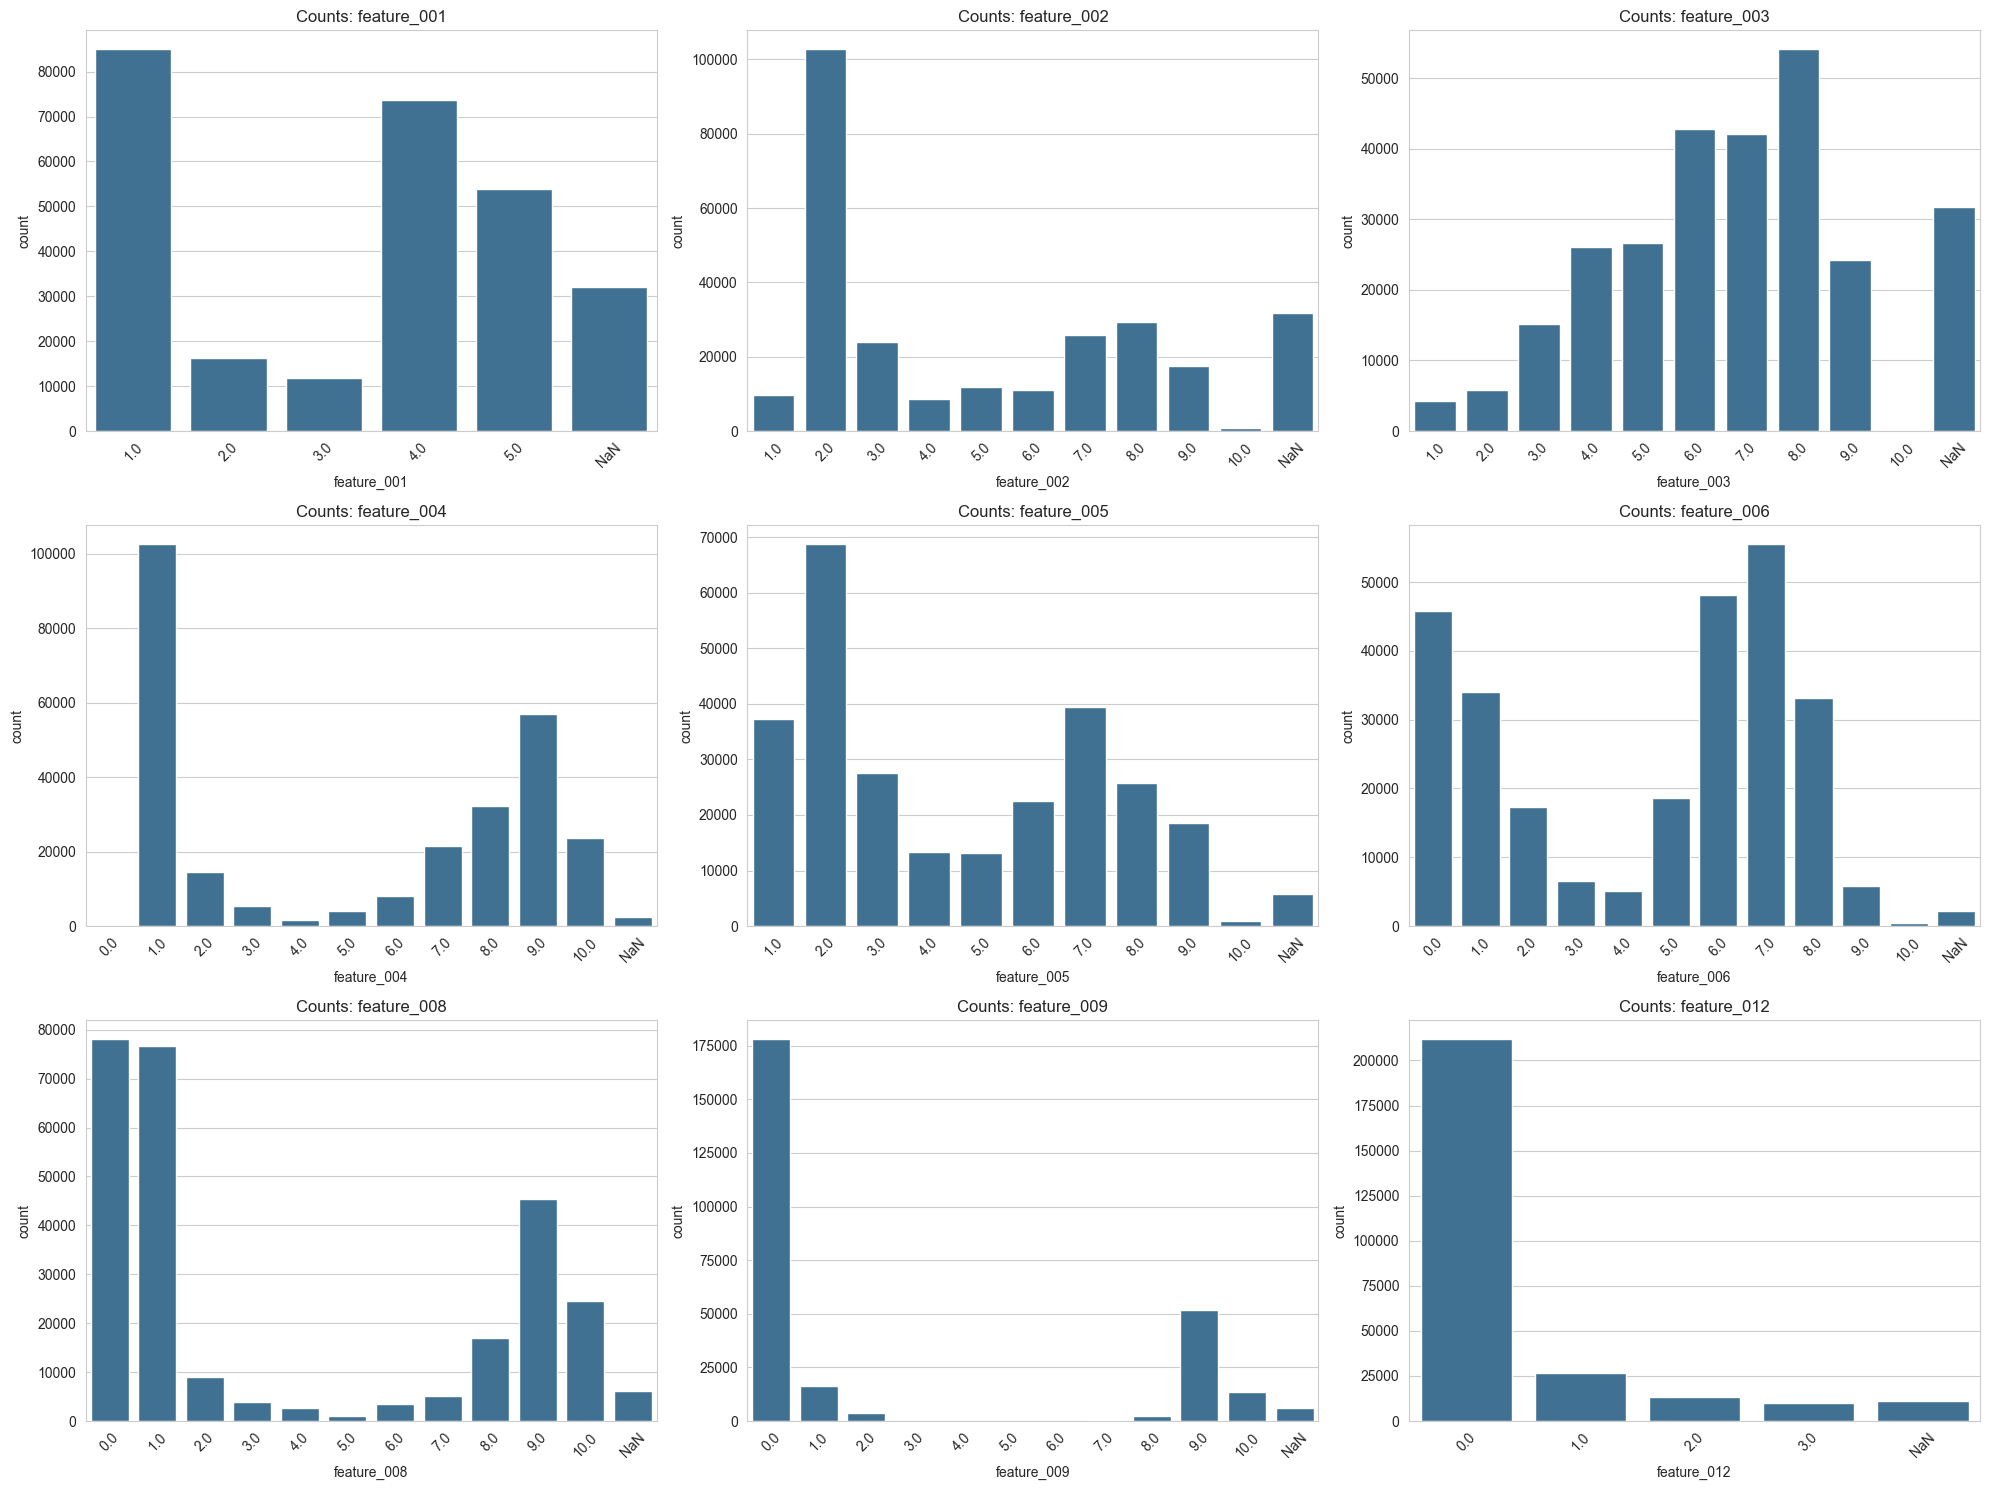

In [ ]:
temp_categorical_features = [
    "feature_001", "feature_002", "feature_003", "feature_004",
    "feature_005", "feature_006", "feature_008", "feature_009",
    "feature_012"
]

def plot_categorical_countplots(
    df: pd.DataFrame,
    features: list[str], 
    n_cols: int = 3
) -> None:
    """
    Plots countplots for features, sorting x-axis numerically even if data is categorical/string.
    Handles 'NaN' by placing it at the end.
    """
    n_rows = math.ceil(len(features) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(features):
        ax = axes[i]
        plot_data = df[col].fillna("NaN").astype(str)
        unique_vals = plot_data.unique()
        def sort_key(val):
            if val == "NaN":
                return float('inf') # Puts NaN at the very end
            try:
                return float(val)  
            except ValueError:
                return val          
        numeric_order = sorted(unique_vals, key=sort_key)
        sns.countplot(x=plot_data, order=numeric_order, ax=ax, color='#3274a1')
        ax.set_title(f"Counts: {col}")
        ax.tick_params(axis='x', rotation=45)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

plot_categorical_countplots(train, temp_categorical_features)

#### Insights & Actions
It appears safe to treat most of the features as unordered categorical data. We can't derive enough information to determine if they are nominal or ordinal, however.
- *Possible Actions*: For tree-based models like `xgboost`, we shouldn't have to do anything at all hear. These models will love these features, and treat `NaN` as it's own categorical value. For NNs, we will experiment with both one-hot encoding, label encoding, and embeddings. One-hot encoding will explode our feature count, but I think we can develop models that can learn from those features well enough. For our baseline tree-based model, no modifications should be necessary to these features.

Let's also plot our binary features for brevity. We should be able to treat these features exactly like our presumed "categoricals".

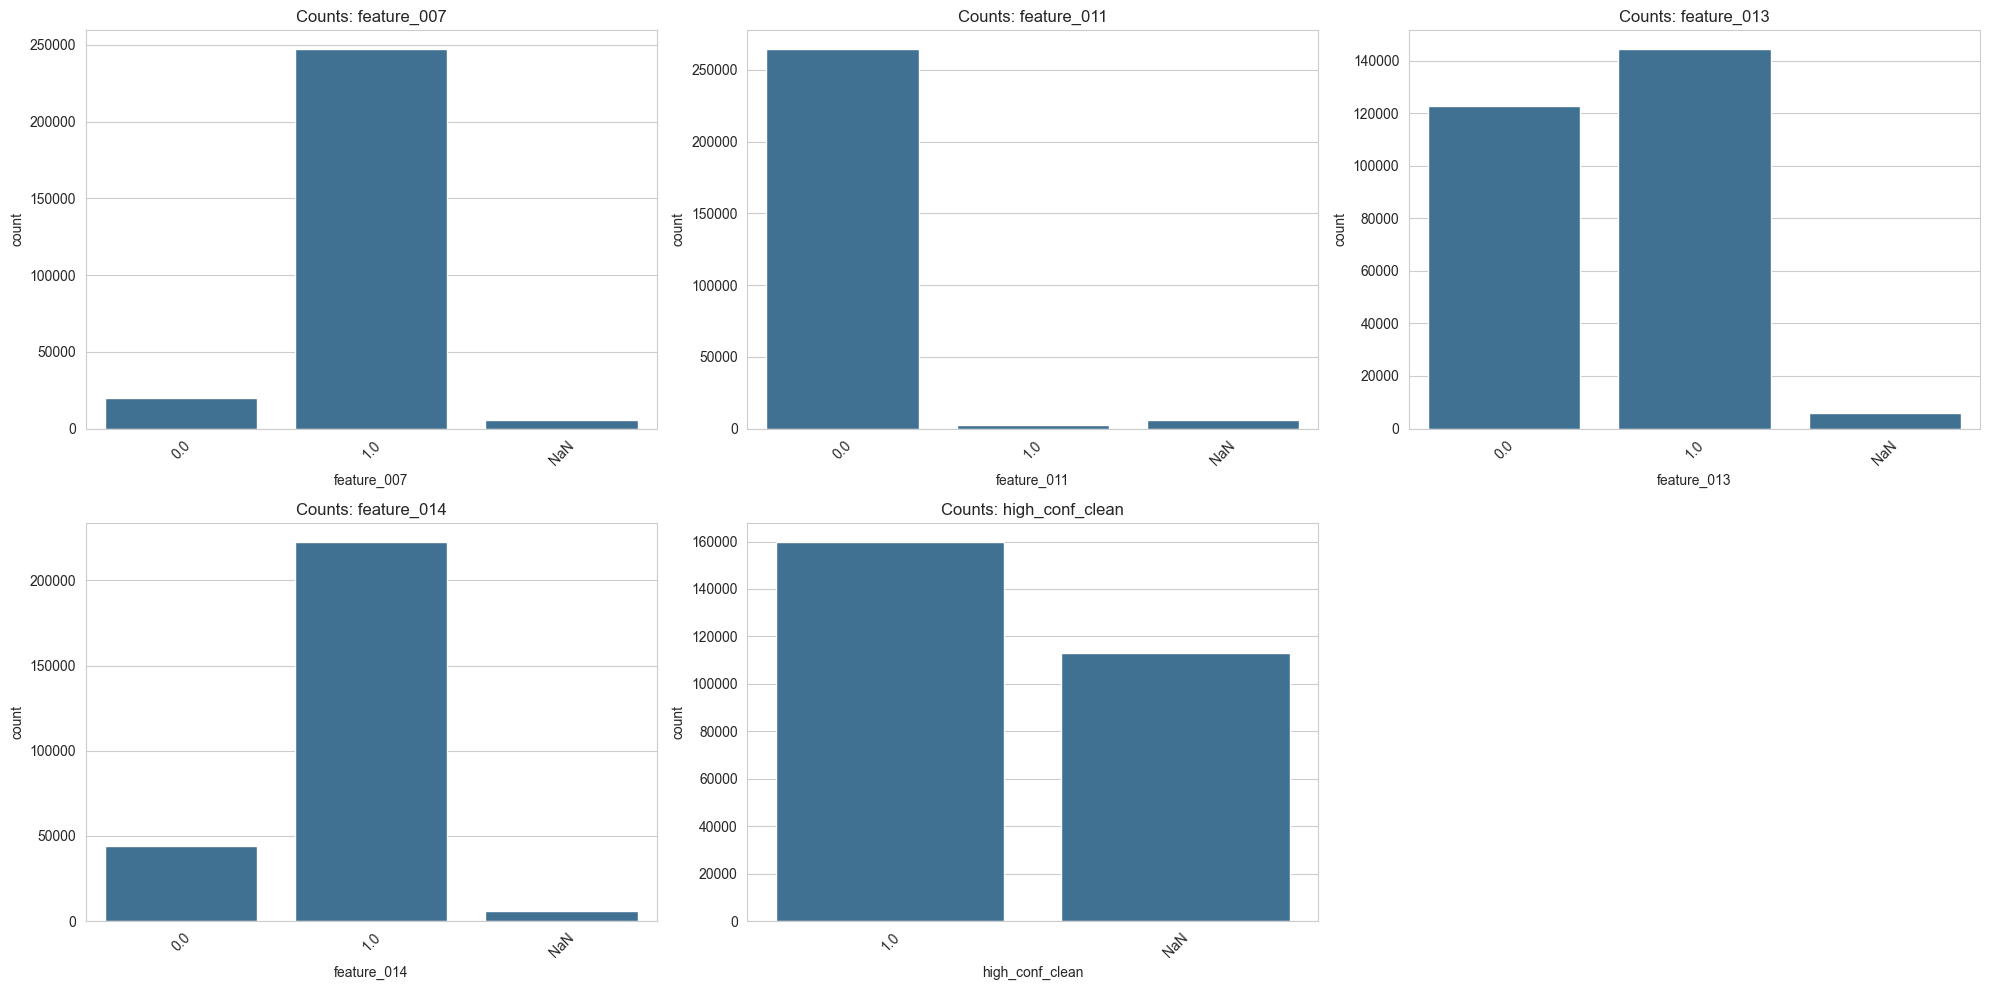

In [11]:
plot_categorical_countplots(train, CFG.BINARY_FEATURES)

- *Additional Note*: `feature_007` and `feature_011` have extremely low variance. For simple models like logistic regression, we should consider dropping these features, as there may not be much those models can learn from these features. We should not drop these features for NNs or tree-based models, as interactions will likely be discovered by the model.

### C. Multivariate Analysis
#### i. Numerical vs. Target
Let's now compare our numerical features to our target.

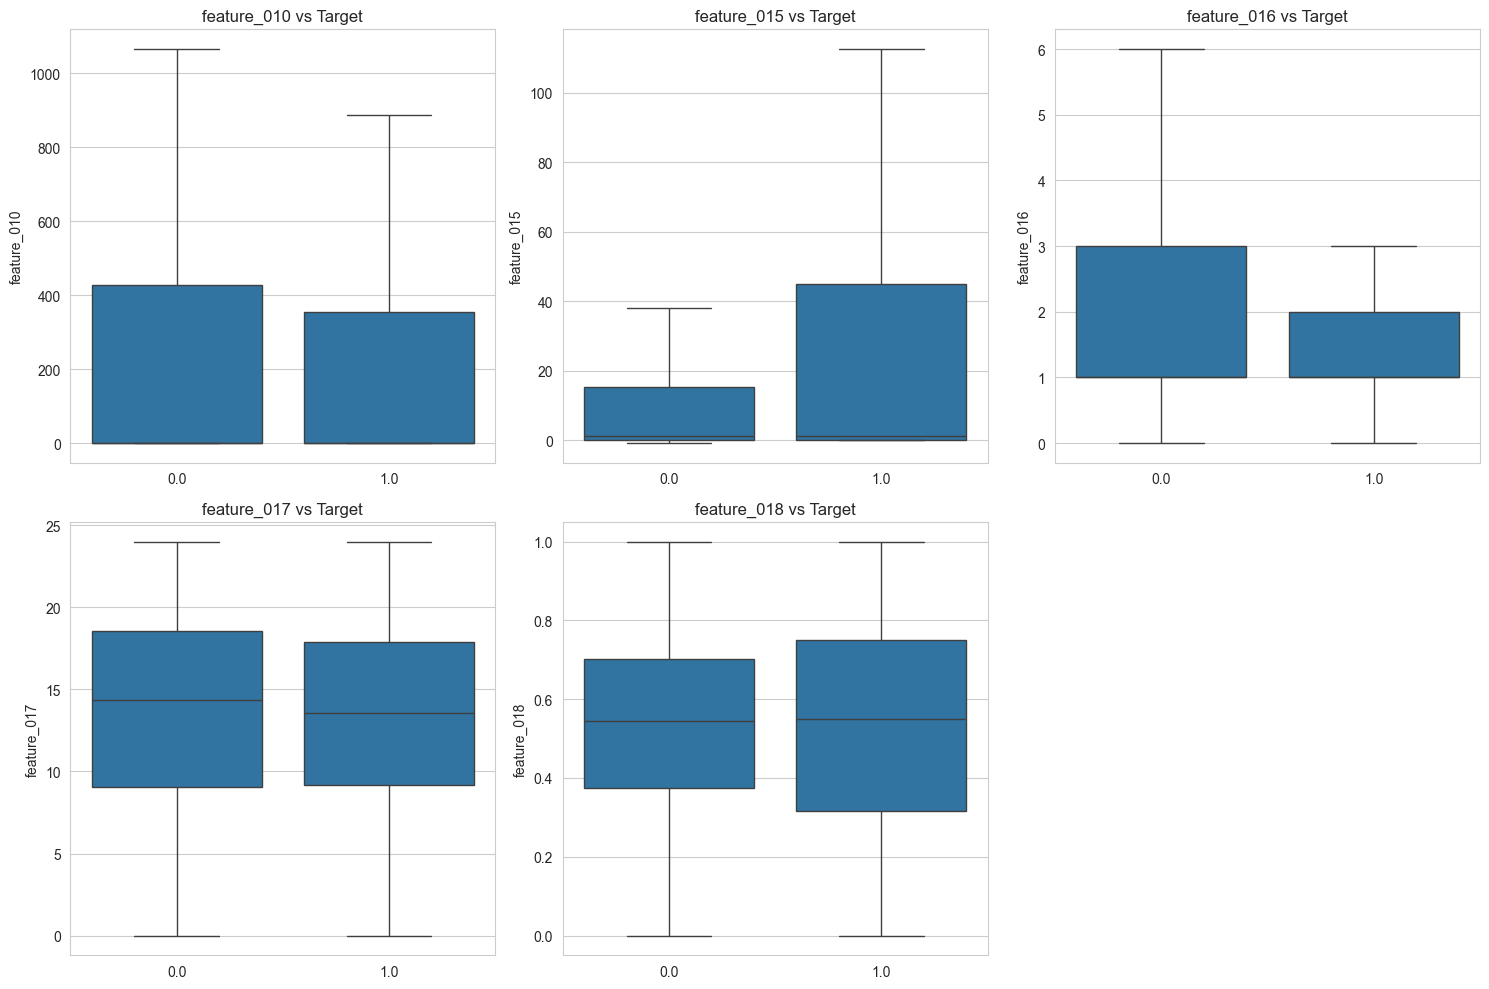

In [12]:
def plot_boxplots(
    df: pd.DataFrame,
    numeric_cols: list[str],
    target: str,
    n_cols: int = 3,
    outliers: bool = False,
    xlabel: str = ""
) -> None:
    """Generates a grid of boxplots comparing numeric columns against a target variable.
    
    This function is useful for analyzing the relationship between continuous features 
    and a categorical target, visualizing distribution spread and central tendency.

    Args:
        df (pd.DataFrame): The input DataFrame containing the data.
        numeric_cols (list[str]): A list of numeric column names (y-axis) to analyze.
        target (str): The name of the categorical column (x-axis) used for grouping.
        n_cols (int, optional): The number of subplots to arrange horizontally. 
            Defaults to 3.
        outliers (bool, optional): If True, displays outlier points (fliers) beyond 
            the whiskers. Defaults to False.
        xlabel (str, optional): A custom label for the x-axis applied to all subplots. 
            Defaults to an empty string.

    Returns:
        None: The function displays a matplotlib figure via `plt.show()` and 
        does not return a value.
    """
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols 
    plt.figure(figsize=(15, 5 * n_rows))
    for i, col in enumerate(numeric_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(data=df, x=target, y=col, showfliers=outliers)
        plt.title(f"{col} vs Target")
        plt.xlabel(xlabel)
    plt.tight_layout()
    plt.show()
    
plot_boxplots(train, temp_numeric_features, CFG.TARGET)

#### Insights
- *Strongest Signals*: `feature_010`, `feature_015`, and `feature_016`. These will make strong features for our tree-based models. We should see an even sharper distinction with `feature_010` and `feature_015` after applying a log transformation.
- *Weakest Signals*: There is still some distinction between a negative and positive determination for `feature_017` and `feature_018`, but a simple linear model may struggle to find information here. Tree-based models and NNs will almost certainly find non-linear relationships.

#### ii. "Categorical" & Binary vs. Target

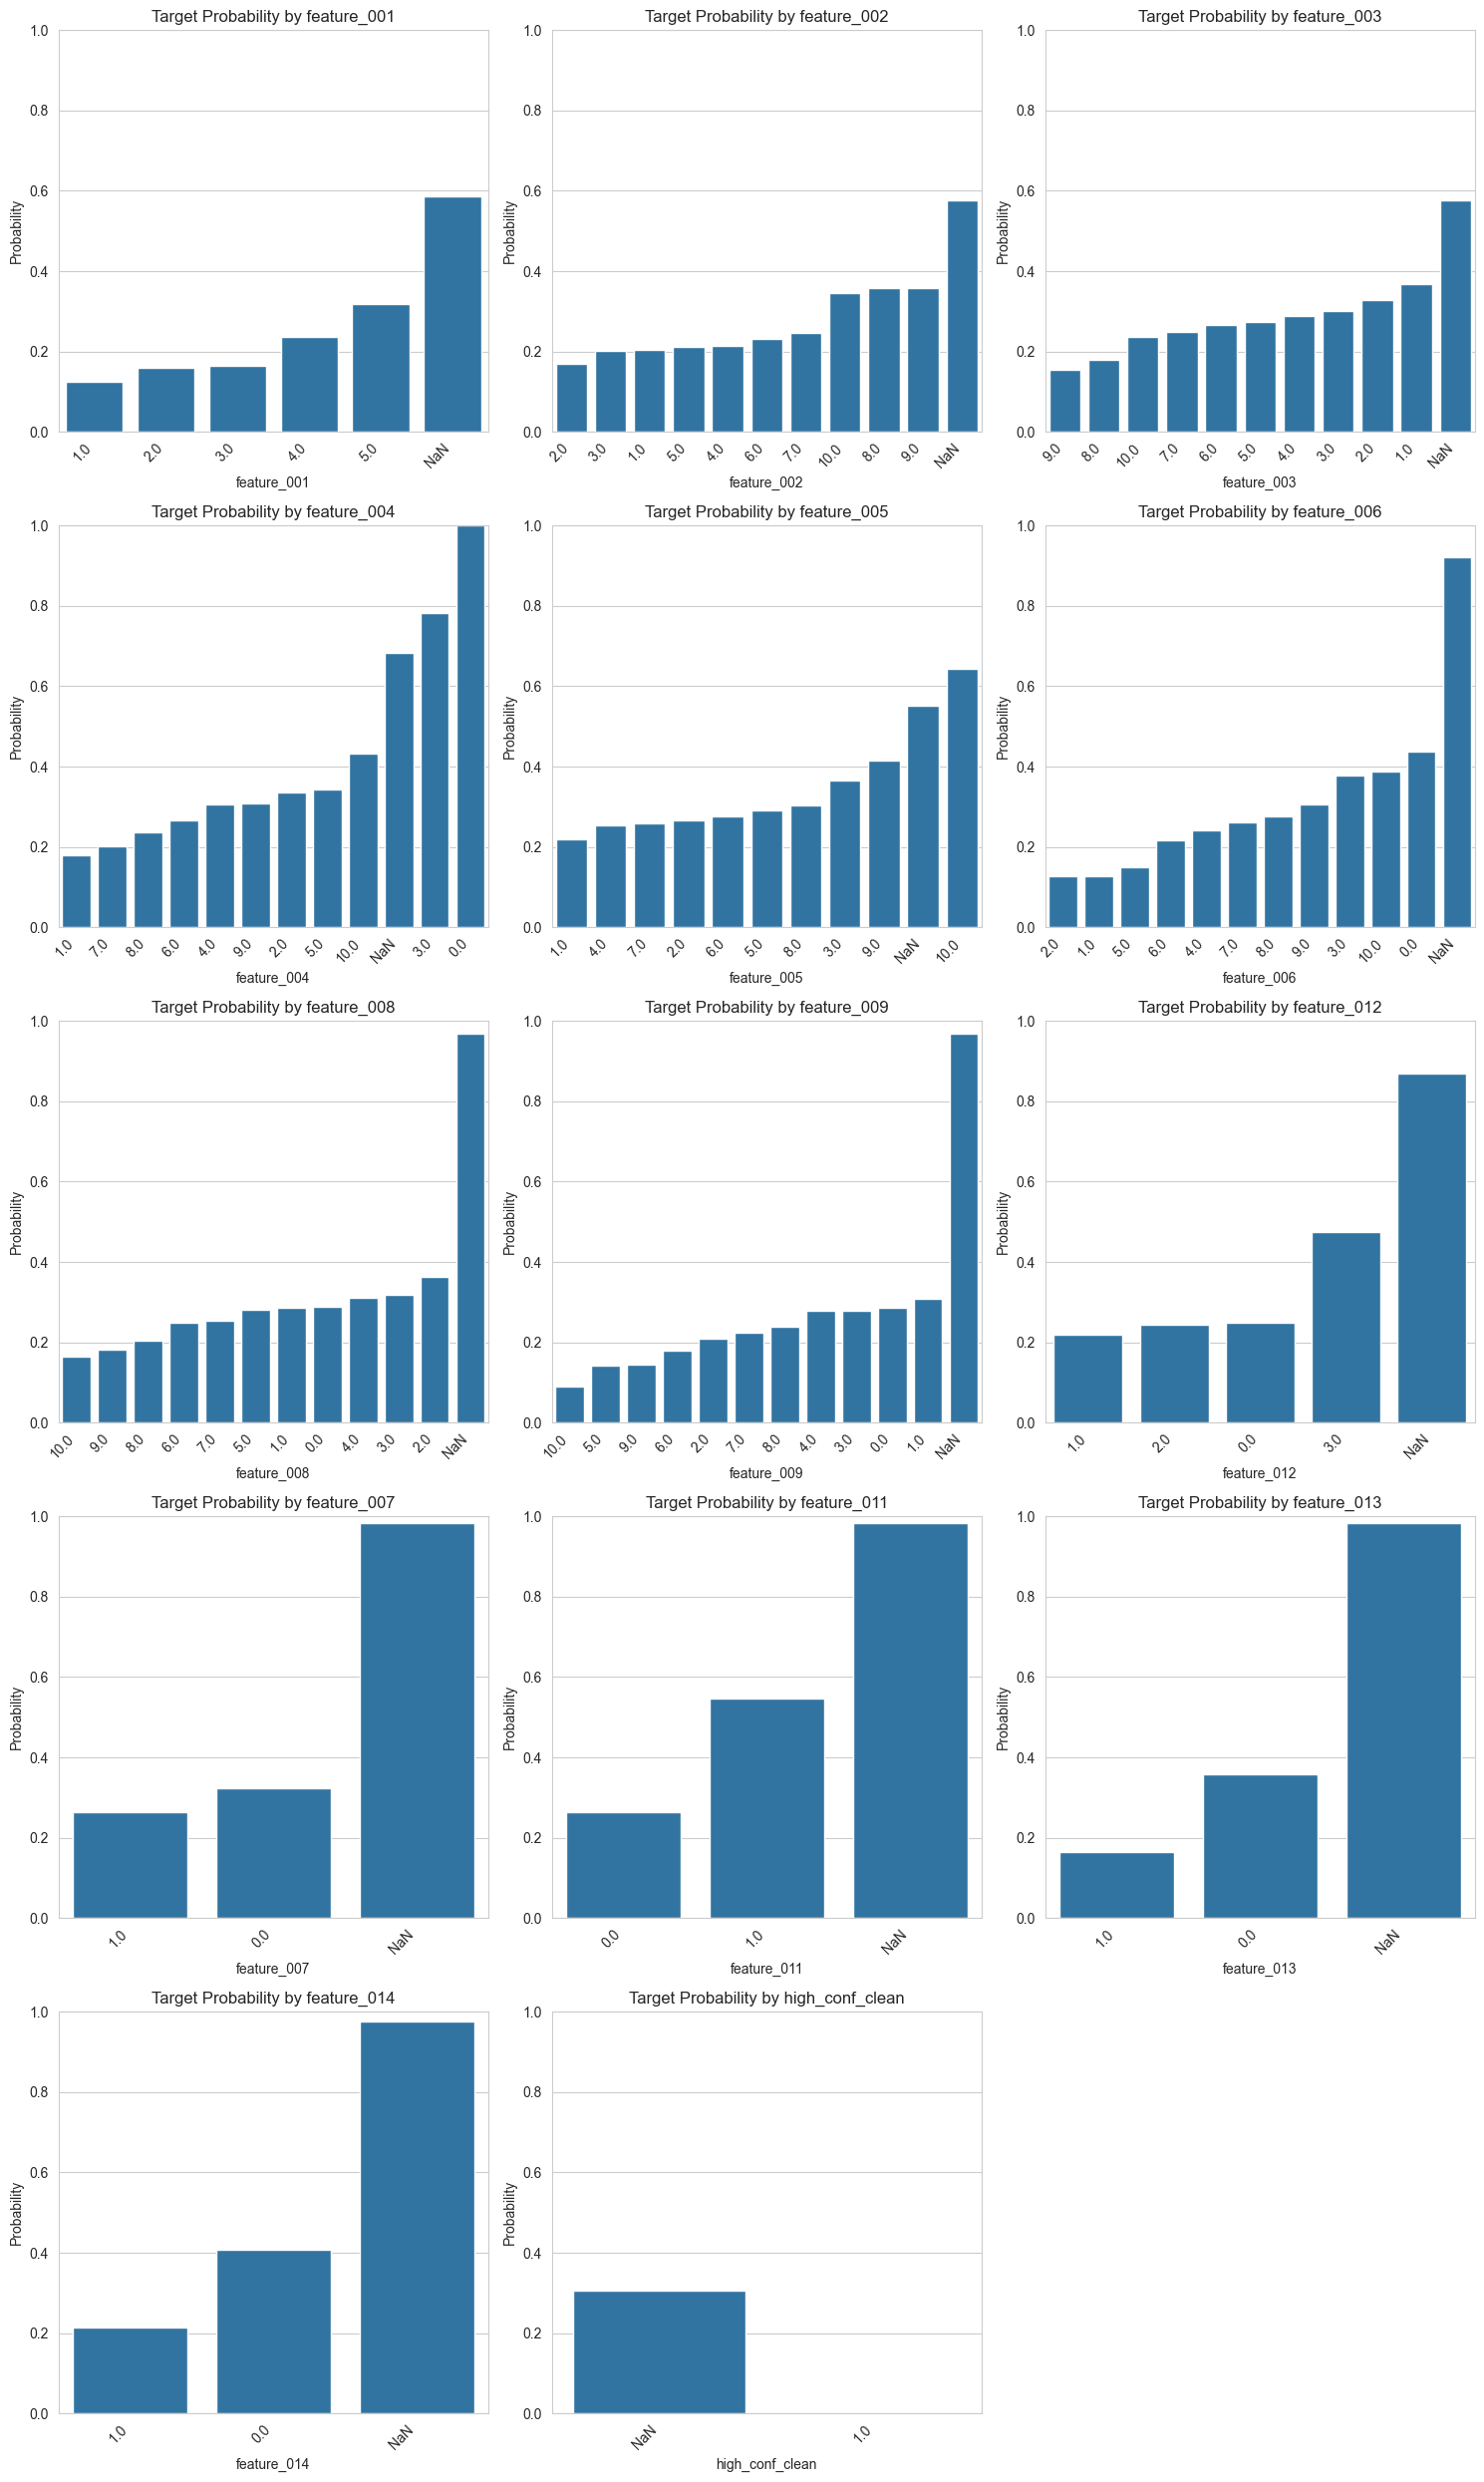

In [ ]:
def plot_barplots(
    df: pd.DataFrame,
    categorical_cols: list[str],
    ordinal_cols: list[str],
    target: str,
    n_cols: int = 3
) -> None:
    
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
    plt.figure(figsize=(15, 5 * n_rows))
    
    for i, col in enumerate(categorical_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Create a temporary series with NaNs filled as a string for plotting
        temp_series = df[col].fillna("NaN")
        
        # Logic to determine ordering
        if col in ordinal_cols:
            # Sort unique values (including "NaN" string)
            order = sorted(temp_series.unique().astype(str))
        else:
            # Sort by target mean (including "NaN" group)
            order = df.assign(temp_col=temp_series).groupby("temp_col")[target].mean().sort_values().index
            
        # Plot using the temporary series for the x-axis
        sns.barplot(
            x=temp_series, 
            y=df[target], 
            order=order, 
            errorbar=None
        )
        
        plt.title(f"Target Probability by {col}")
        plt.ylim(0, 1)
        plt.ylabel("Probability")
        plt.xlabel(col)
        plt.xticks(rotation=45, ha="right")
        
    plt.tight_layout()
    plt.show()

plot_barplots(train, temp_categorical_features + CFG.BINARY_FEATURES, [None], CFG.TARGET)

#### Insights
- Nothing suprising here, we simply affirm our assumptions above that `NaN` holds significant predictive power. We must treat `NaN` as it's own categorical value within these features.
- Linear models could struggle with some of these features, particularly features `002` through `006`, the reason being the distinction between some values and the probability of the target is not as easily distinguishable. Again, experimenting with one-hot and label encoding, as well as embeddings, will be cruicial here, especially to convert the binary features to a categorical.

### D. Correlations & Interactions
i. Missingness Correlations

<Axes: >

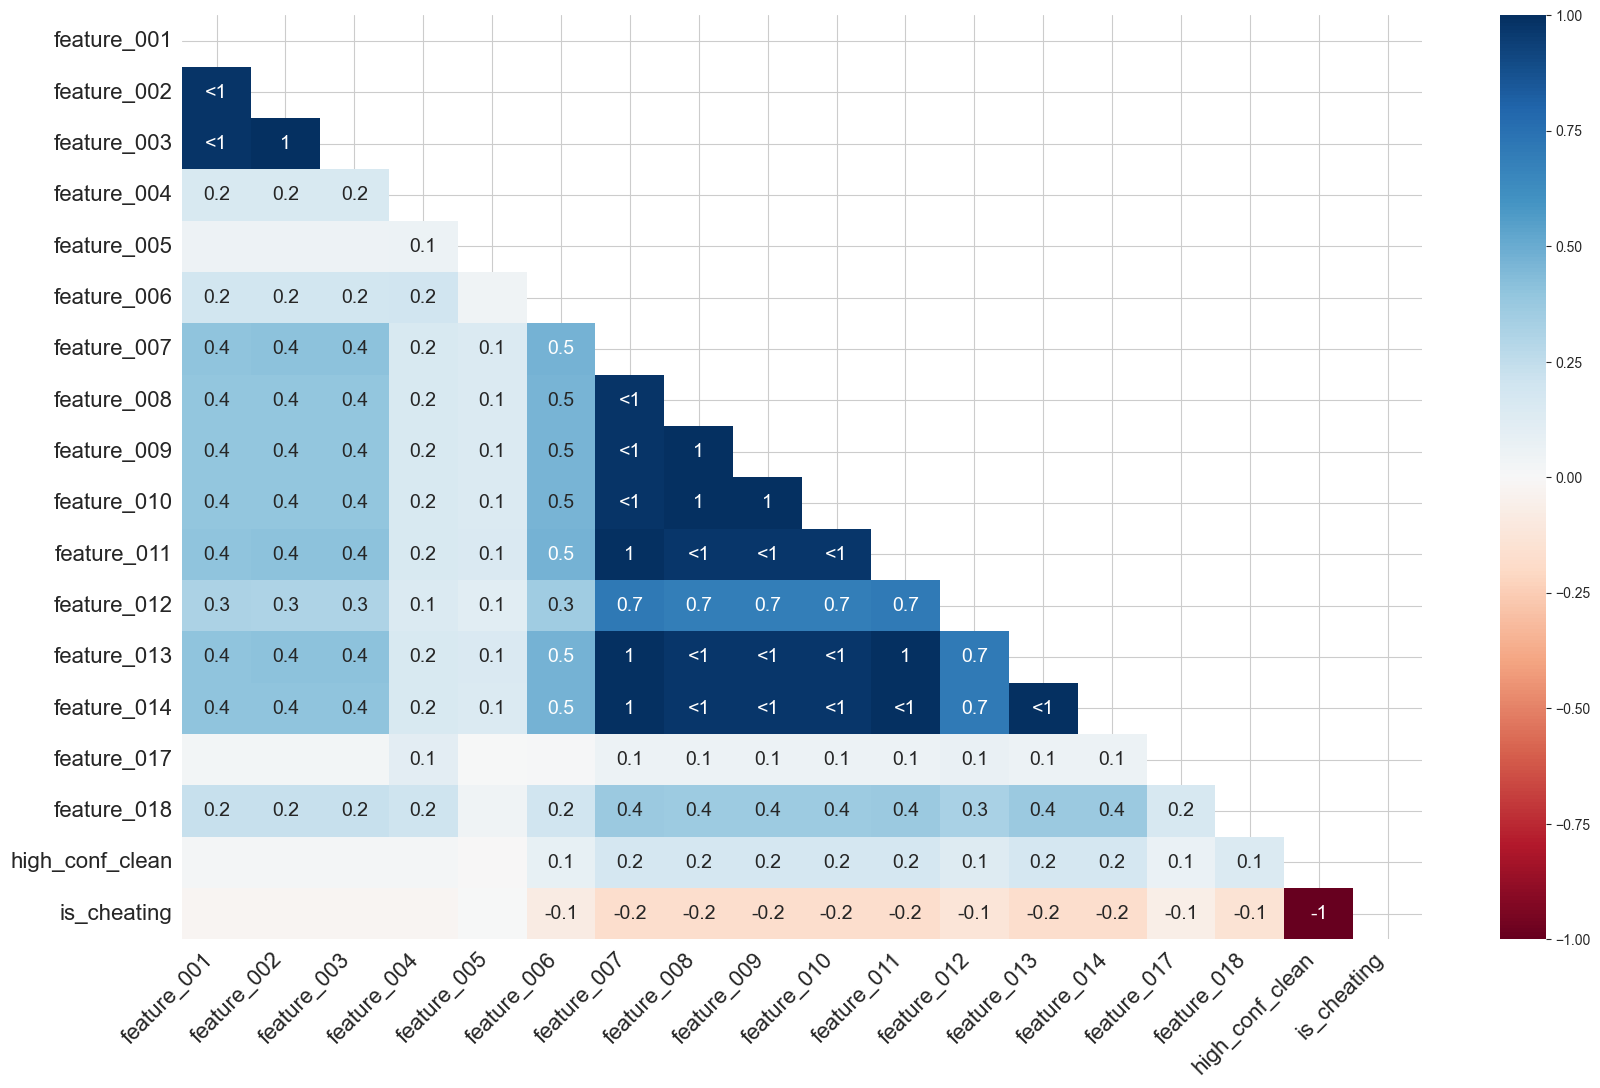

In [14]:
import missingno as msno
msno.heatmap(train)

#### Insights
Not only have we validated our hypothesis above, but we can expand on the correlation of missingness to define 3 distinct groups.
- Group_A: `feature_002` and `feature_003`
- Groub_B: `feature_009` and `feature_010`
- Group_C: `feature_007`, `feature_008`, `feature_013`, and `feature_014`.

*Possible Actions*: 
- We should create a missing indicator feature for each of these three groups. Something along the lines of `is_group_c_missing`. This could help linear models especially. 
- Most of these features are categorical, and we have already determined that we are treating `NaN` as one of these categories. 
- We will impute the missing values of `feature_010` with either the median value or a negative value that doesn't exist in the series, but only have createing `is_group_B_missing`. The new feature will act as our indicator for `feature_010`. 

*Full Imputation Strategy*:
- For the "categoricals", convert `NaN` to `-1` to indicate it's own unique categorical value.
- Create `is_missing_group_B` binary feature, and impute `feature_010`s missing values with the median value.
- Create `feature_016_is_missing` and impute the missing values of `feature_016` with the median value.
- Apply a cyclic transformation to `feature_017`, creating features `feature_017_cos` and `feature_017_sin`. We should do this after creating `feature_017_is_missing` and imputing `feature_017` with it's median value.
- Create `feature_018_is_missing` and impute the missing values of `feature_018` with the median value.

#### ii. Correlation Matrix

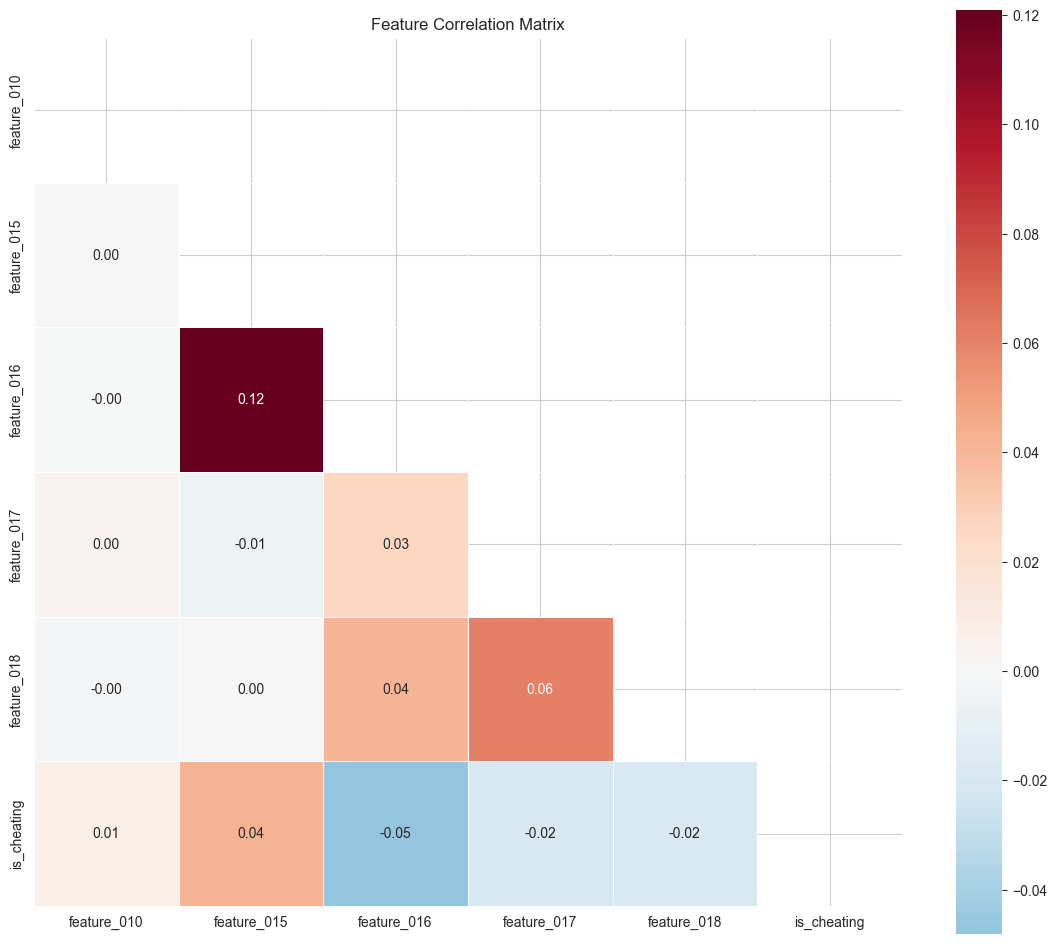

In [15]:
def create_correlation_matrix(
    df: pd.DataFrame,
    numeric_cols: list[str],
    target: str,
    figsize: tuple[int, int] = (14, 12),
    cmap: str = "RdBu_r",
    title: str = "Feature Correlation Matrix"
) -> None:
    """
    Calculates and displays a correlation matrix heatmap for numeric features.

    This function computes the pairwise correlation (Pearson) between specified 
    numeric columns and the target variable. It applies a mask to hide the upper 
    triangle of the heatmap to reduce visual clutter.

    Args:
        df (pd.DataFrame): The input DataFrame containing the data.
        numeric_cols (list[str]): A list of numeric feature names to include.
        target (str): The name of the target variable to include in the matrix.
        figsize (tuple[int, int], optional): The width and height of the figure 
            in inches. Defaults to (14, 12).
        cmap (str, optional): The mapping from data values to color space. 
            Defaults to "RdBu_r" (Red-Blue, diverging).
        title (str, optional): The title of the plot. Defaults to "Feature 
            Correlation Matrix".

    Returns:
        None: The function displays a matplotlib figure via `plt.show()` and 
        does not return a value.
    """
    # Ensure target isn't duplicated if it's already in numeric_cols
    cols_to_plot = numeric_cols + [target] if target not in numeric_cols else numeric_cols
    
    numeric_df = df[cols_to_plot]
    corr_matrix = numeric_df.corr()
    
    plt.figure(figsize=figsize)
    
    # Create a mask for the upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
    
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        annot=True, 
        fmt=".2f", 
        cmap=cmap, 
        center=0, 
        square=True, 
        linewidths=.5
    )
    plt.title(title)
    plt.show()
    
create_correlation_matrix(train, temp_numeric_features, CFG.TARGET)

#### Insights
- Nothing significant to note here for most models. Our numeric features are not highly correlated with each other.
- For linear models, these numeric features may struggle to provide much predictive information when determining our target. We could experiment with interactions here.
- If `feature_017` truly is a feature related to time, we might gain some predictive power by creating features like "is_night" or "is_office_hours". This is beyond the scope of our baseline, but will be something to consider going forward.

#### iii. Mutual Information
Let's create a couple of plots, both with the raw features and some temporary engineered features. We want to see if we are on the right track with at least some of our feature processing and imputation strategies.

C:\Users\collinsz\AppData\Local\Temp\ipykernel_9032\3017301824.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")


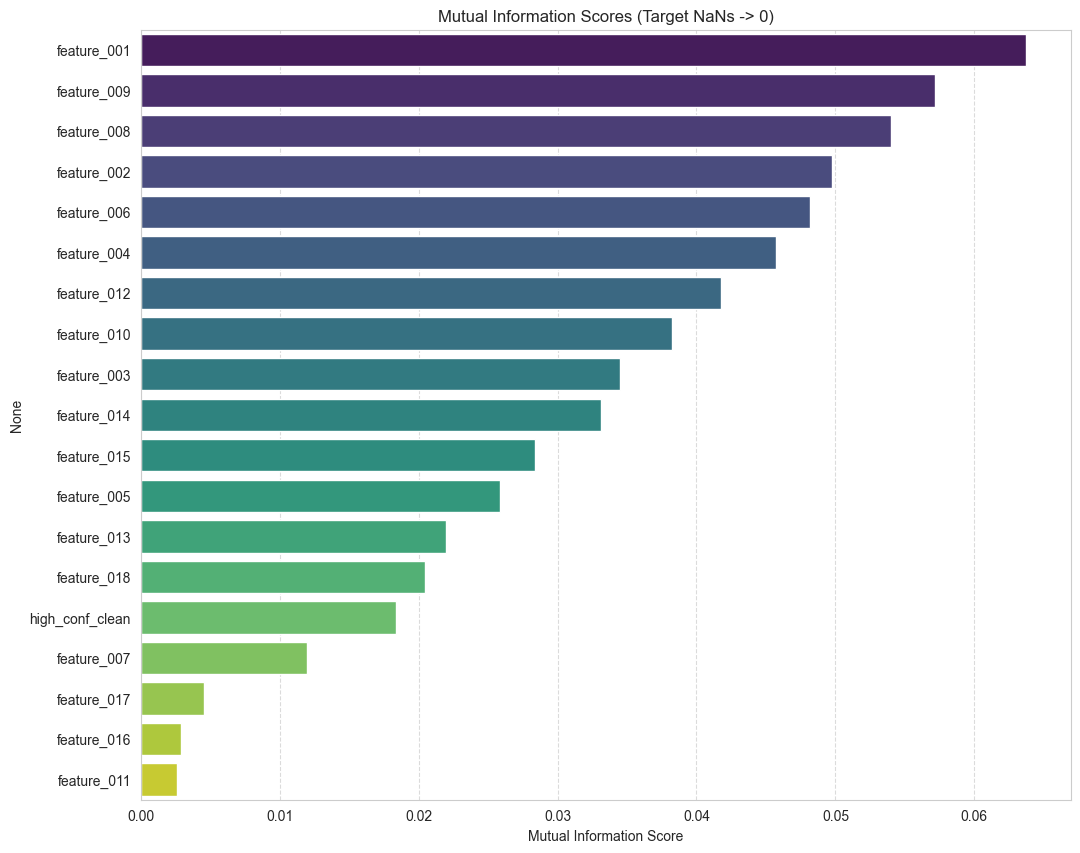

In [17]:
def plot_mi_scores(
    df: pd.DataFrame,
    target: str,
    categorical_cols: list[str],
    sample_size: int = 100_000,
    seed: int = 15,
    title: str = None,
    figsize: tuple[int, int] = (12, 10)
) -> pd.Series:
    
    df_sample = df.sample(min(sample_size, len(df)), random_state=seed).copy()
    
    y = df_sample[target].fillna(0).astype(int)
    X = df_sample.drop(columns=[target])
    
    for col in X.columns:
        if col in categorical_cols:
            X[col] = X[col].fillna("Missing").astype(str)
        else:
            X[col] = X[col].fillna(X[col].median())
            
    if categorical_cols:
        oe = OrdinalEncoder()
        X[categorical_cols] = oe.fit_transform(X[categorical_cols])

    discrete_mask = [col in categorical_cols for col in X.columns]
    
    mi_scores = mutual_info_classif(
        X, y, 
        discrete_features=discrete_mask, 
        random_state=seed
    )
    
    mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=figsize)
    sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")
    plt.title(title if title else "Mutual Information Scores (Target NaNs -> 0)")
    plt.xlabel("Mutual Information Score")
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.show()
    
    return mi_series

mi_results = plot_mi_scores(train.drop(columns=["user_hash"]), CFG.TARGET, temp_categorical_features)

C:\Users\collinsz\AppData\Local\Temp\ipykernel_9032\3017301824.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")


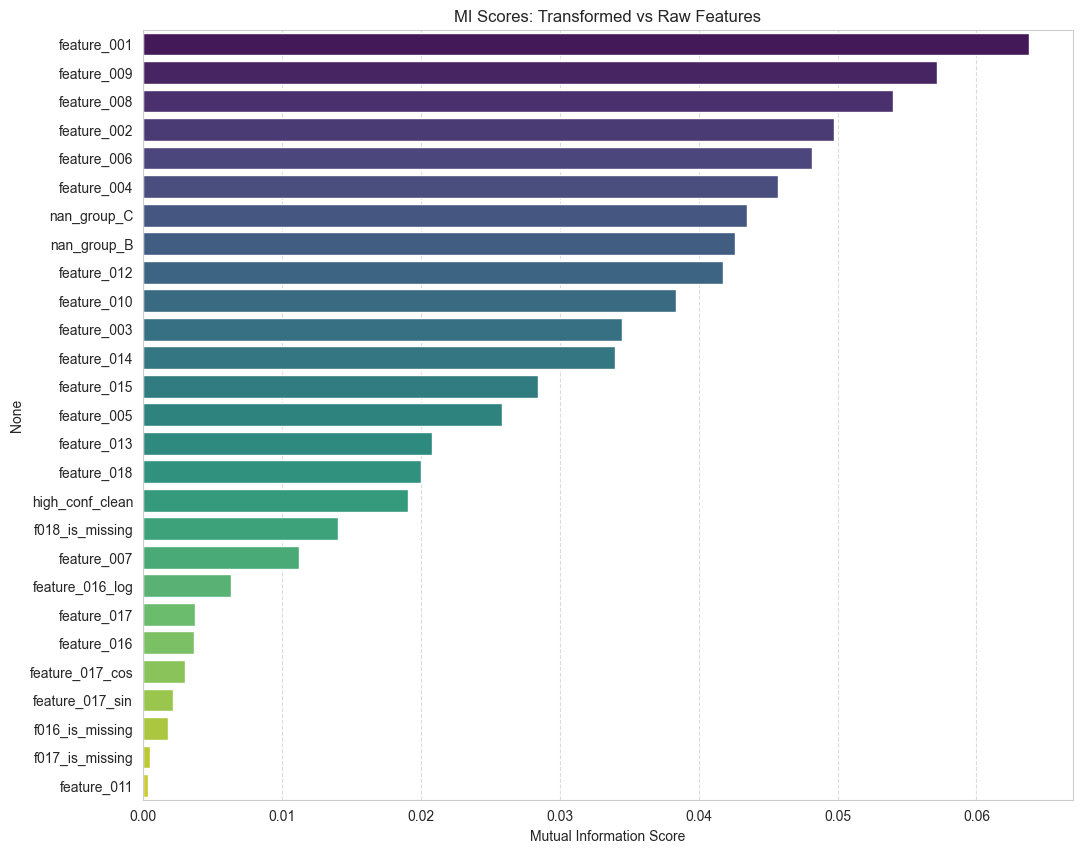

In [18]:
# Use temporary feature engineer
def apply_feature_engineering(
    df: pd.DataFrame
) -> pd.DataFrame:
    """Temporary feature engineer."""
    df = df.copy()
    df['nan_group_B'] = df['feature_010'].isnull().astype(int)
    df['nan_group_C'] = df['feature_008'].isnull().astype(int)
    df['f016_is_missing'] = df['feature_016'].isnull().astype(int)
    f016_median = df['feature_016'].median()
    df['feature_016_log'] = np.log1p(df['feature_016'].fillna(f016_median))
    df['f017_is_missing'] = df['feature_017'].isnull().astype(int)
    f017_median = df['feature_017'].median()
    temp_017 = df['feature_017'].fillna(f017_median)
    df['feature_017_sin'] = np.sin(2 * np.pi * temp_017 / 24.0)
    df['feature_017_cos'] = np.cos(2 * np.pi * temp_017 / 24.0)
    df['f018_is_missing'] = df['feature_018'].isnull().astype(int)
    df['feature_018'] = df['feature_018'].fillna(df['feature_018'].median())
    return df

train_eng = apply_feature_engineering(train)
transformed_features = [
    'feature_016_log', 'feature_016_is_missing',
    'feature_017_sin', 'feature_017_cos', 'feature_017_is_missing',
    'nan_group_A', 'nan_group_B', 'nan_group_C'
]

new_mi_results = plot_mi_scores(
    train_eng.drop(columns=["user_hash"]), 
    target=CFG.TARGET, 
    categorical_cols=temp_categorical_features, # Keep original categorical columns here
    title="MI Scores: Transformed vs Raw Features"
)

#### Insights
- `feature_016`, `feature_017` and `feature_011` have little signal.
- Creating `nan_Group_B` and `nan_Group_A` was a fantastic idea, as they are providing significant value.
- `feature_011` may actually need to be dropped, even for a tree-based model or NN. We will experiment with this in another workflow, but it's signal is negligible.

### E. Social Graph
We will now inspect the social graph. Let's first create this graph with `neworkx`.

In [19]:
G = nx.from_pandas_edgelist(social_graph, source="user_a", target="user_b")

Let's first check to see if our more socially active users behave differently than "loners." We also seperate all friends from friends in our dataset ("Total Degree", "Internal Degree", respectively.)

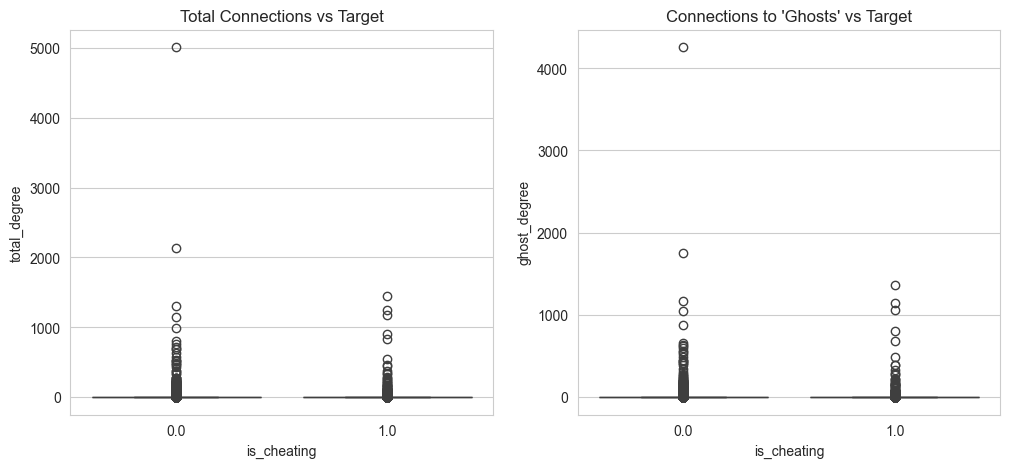

In [20]:
degree_map = dict(G.degree())
train["total_degree"] = train["user_hash"].map(degree_map).fillna(0)

# Nodes in G that are NOT in train['user_hash'] are ghosts
train_users = set(train["user_hash"])
def get_internal_degree(user):
    if user not in G: return 0
    return len([n for n in G.neighbors(user) if n in train_users])

train["internal_degree"] = train["user_hash"].apply(get_internal_degree)
train["ghost_degree"] = train["total_degree"] - train["internal_degree"]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=train, x=CFG.TARGET, y="total_degree")
plt.title("Total Connections vs Target")

plt.subplot(1, 2, 2)
sns.boxplot(data=train, x=CFG.TARGET, y="ghost_degree")
plt.title("Connections to 'Ghosts' vs Target")
plt.show()

This doesn't give us much insight. Let's try an inspect the "neighborhood", specifically, let's see if having "bad neighbors" makes a user "bad."

In [21]:
target_lookup = train.set_index("user_hash")[CFG.TARGET].fillna(0).to_dict()

# helper
def get_neighbor_stats(user):
    if user not in G: return 0.0
    neighbors = [n for n in G.neighbors(user) if n in target_lookup]
    if not neighbors: return 0.0
    # Calculate mean target of neighbors
    return np.mean([target_lookup[n] for n in neighbors])

train["neighbor_target_mean"] = train["user_hash"].apply(get_neighbor_stats)

correlation = train[[CFG.TARGET, "neighbor_target_mean"]].corr().iloc[0, 1]
print(f"Correlation between User Target and Neighbor Target Mean: {correlation:.4f}")

Correlation between User Target and Neighbor Target Mean: 0.1599


#### Insights
- We should create the feature "neighbor_target_mean", even for our baseline. This is significant predictive power.

Let's do more inspection on a user's social network size. We can check to see if a user belongs to a large group, or an isolated "island."

Target Probability: island (<=2 nodes) vs mainland
is_on_island
0    0.267386
1    0.397815
Name: is_cheating, dtype: float64


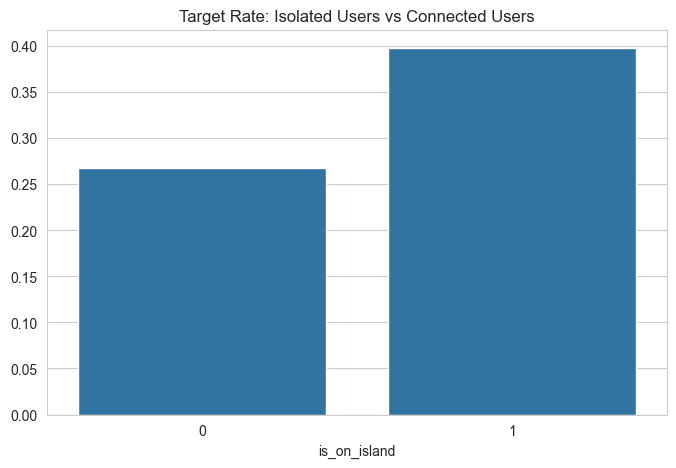

In [22]:
components = list(nx.connected_components(G))
# Map each user to their component size
comp_size_map = {node: len(c) for c in components for node in c}

train["component_size"] = train["user_hash"].map(comp_size_map).fillna(0)

# On an island or on the mainland?
train["is_on_island"] = (train["component_size"] <= 2).astype(int)

# analyze target density
island_analysis = train.groupby("is_on_island")[CFG.TARGET].mean()
print("Target Probability: island (<=2 nodes) vs mainland")
print(island_analysis)

plt.figure(figsize=(8, 5))
sns.barplot(x=island_analysis.index, y=island_analysis.values)
plt.title("Target Rate: Isolated Users vs Connected Users")
plt.show()

#### Insights
- Users on "islands" have a 40% target rate, while users on the "mainland" have a 27% rate.
- Isolation is a predictor. These lonely individuals seem to often exhibit the target behavior more frequently than well-integrated social users.
- *Possible Actions*: Create the `is_on_island` feature.

Next, let's perform a "guilty by association analysis". What this means, is that we want to answer the question, if a ghost user (a user with no data) is the common connection for "x" amount of different `is_cheating == 1` users, is that ghost a central hub for cheating behavior?

In [23]:
# helper
def find_suspicious_ghost_hubs(train_df, social_df):
    # Filter for only known positives
    pos_users = set(train_df[train_df[CFG.TARGET] == 1]["user_hash"])
    all_known_users = set(train_df["user_hash"])
    # We want to find who the 'red-flag' users are talking to
    ghost_connections = []
    for _, row in social_df.iterrows():
        u_a, u_b = row["user_a"], row["user_b"]
        # If A is a positive user, check if B is a ghost
        if u_a in pos_users and u_b not in all_known_users:
            ghost_connections.append(u_b)
        # If B is a positive user, check if A is a ghost
        if u_b in pos_users and u_a not in all_known_users:
            ghost_connections.append(u_a)
    hub_counts = Counter(ghost_connections)
    hub_df = pd.DataFrame(hub_counts.items(), columns=["ghost_id", "pos_neighbor_count"])
    hub_df = hub_df.sort_values("pos_neighbor_count", ascending=False)
    return hub_df

ghost_hubs = find_suspicious_ghost_hubs(train, social_graph)
print("Top 'ghost' hubs:")
print(ghost_hubs.head(10))

Top 'ghost' hubs:
              ghost_id  pos_neighbor_count
6     9918c66f6114eaa6                4951
10    fbc2dcd0d05b96c7                1692
30    82bc3a6da17c4704                1201
270   f112436d0d71119c                 589
2435  22ccf605d300d474                 424
6584  9c87ba0b24de5f03                 386
43    1589d644ac63080d                 369
23    16ba2270c5c74d12                 276
7330  98b4f57f0f02d21c                 225
213   8ba30474fd20b190                 209


#### Insights
- These hubs likely represent a shared infrastructure. 4951 seperate target case connections seems almost impossible for a normal social connection.
- It is possibe that those users are all connected to each other.
- *Possible Actions*: We should consider creating a `ghost_risk` feature that can quantify connections to red-flag ghost hubs.

### F. Preprocessing and Cleaning Summarization
1. Cleaning & Imputation
    - "Categorical" features: Convert `NaN` to `-1`. Do not scale these features.
    - Create `is_missing_group_A`, `is_missing_group_B`, `is_missing_group_C` binary features.
    - Create `is_missing_010`, then impute `feature_010` with median.
    - Drop the two rows of data where `feature_015` is negative.
    - Create `is_missing_017` and impute with the median.
    - Create `is_missing_018` and impute with the median.

2. Feature Engineering & Scaling
    - Apply log transformations to `feature_010`, `feature_015`, and `feature_016`. 
    - Create `feature_017_cos` and `feature_017_sin`.
    - Create `is_night`, `is_office_hours` from `feature_017` as binary features.
    - Consider embeddings the "categorical" features. We can also experiment with one-hot or label encoding later.
    - Create `is_missing_from_graph` binary feature.
    - Create `total_degree`, `internal_degree`, and `ghost_degree` features. We may need to consider a log transformation on `total_degree`.
    - Create the risk metrics `neighbor_target_mean` and `ghost_risk`.

**Final Note on Processing**: For a tree-based model, no additional scaling will be required. For a neural network, we will need to scale the features `feature_010`, `feature_015`, `feature_016`, `feature_017_sin/cos`, `feature_017` (if not dropping it), `total_degree`, `internal_degree`, `ghost_degree`, `neighbor_target_mean`, and `ghost_risk`.

## IV. Data Processing & Cleaning
### A. Prepare and Split Data
Before we can begin structuring the pipeline and splititng data, etc, we must handle the target cleaning and outlier removal to ensure the stratified split is valid.

In [68]:
# Get fresh data
train = pd.read_csv(CFG.TRAIN_PATH)
test = pd.read_csv(CFG.TEST_PATH)
sample = pd.read_csv(CFG.SAMPLE_SUB_PATH)
social_graph = pd.read_csv(CFG.SOCIAL_GRAPH_PATH)

# Prepare the target
train[CFG.TARGET] = train[CFG.TARGET].fillna(0).astype(int)

# Remove outliers immediately
train = train[train["feature_015"] >= 0].reset_index(drop=True)

X = train.drop(columns=[CFG.TARGET, "high_conf_clean"])
y = train[CFG.TARGET]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=CFG.VALID_SIZE, random_state=CFG.SEED, stratify=y
)

print(f"X train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")
print(f"Test shape: {test.shape}")
print(f"Sample submission shape: {sample.shape}")

X train shape: (245535, 19)
y_train shape: (245535,)
X_valid shape: (27282, 19)
y_valid shape: (27282,)
Test shape: (48416, 19)
Sample submission shape: (48416, 2)


### B. Processing
#### i. Imputation and Feature Engineering
Let's create our FeatureEngineer and implement it so it handles our imputation as well. We will also initialize lists of the numeric columns we are imputing with median values, as well as a list of the numeric columns we are performing a log transformation on. This makes it easier for us to experiment with different changes later. We should also consider other imputation values, like the "mean" or other methods entirely. The median is perfect for a baseline, especially with the binary flags we are creating.

In [69]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(
            self, 
            social_df: pd.DataFrame,
            num_median_cols: list[str],
            num_log_cols: list[str],
            target: str,
            cols_to_drop: list[str | None] = [None],
            connection_confidence: int = 2,   
        ):
        self.social_df = social_df
        self.G = nx.from_pandas_edgelist(social_df, source="user_a", target="user_b")
        self.medians = {}
        self.ghost_risk_map = {}
        self.train_target_map = {}
        self.num_median_cols = num_median_cols
        self.num_log_cols = num_log_cols
        self.cols_to_drop = cols_to_drop
        self.target = target
        self.connection_confidence = connection_confidence

    def fit(self, X, y):
        # We need y to calculate neighbor risk and ghost hub toxicity
        temp_df = pd.DataFrame({"user_hash": X["user_hash"], self.target: y})
        self.train_target_map = temp_df.set_index("user_hash")[self.target].to_dict()
        # Calculate intelligent risk
        all_nodes = set(self.G.nodes())
        train_users = set(X["user_hash"])
        ghost_nodes = all_nodes - train_users
        
        for ghost in ghost_nodes:
            neighbors = list(self.G.neighbors(ghost))
            known_neighbors = [n for n in neighbors if n in self.train_target_map]
            if len(known_neighbors) >= self.connection_confidence:
                risk = np.mean([self.train_target_map[n] for n in known_neighbors])
                self.ghost_risk_map[ghost] = risk

        for col in self.num_median_cols:
            if col in X.columns:
                self.medians[col] = X[col].median()
                
        self.is_fitted_ = True
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # Binary missing flags and median imputations
        X["is_missing_group_A"] = X[["feature_002", "feature_003"]].isnull().any(axis=1).astype(int)
        X["is_missing_group_B"] = X[["feature_009", "feature_010"]].isnull().any(axis=1).astype(int)
        X["is_missing_group_C"] = X[["feature_007", "feature_008", "feature_013", "feature_014"]].isnull().any(axis=1).astype(int)
        
        for col in ["feature_017", "feature_018"]:
            X[f"is_missing_{col[-3:]}"] = X[col].isnull().astype(int)
            X[col] = X[col].fillna(self.medians.get(col, 0))
            
        X["feature_010"] = X["feature_010"].fillna(self.medians.get("feature_010", 0))
        
        # Impute "categorical" `NaN` with -1
        cat_cols = [f"feature_{str(i).zfill(3)}" for i in range(1, 15) if i != 10]
        X[cat_cols] = X[cat_cols].fillna(-1)

        # Graph features
        X["is_missing_from_graph"] = X["user_hash"].apply(lambda x: 1 if x not in self.G else 0)
        
        # Degree metrics
        train_users = set(self.train_target_map.keys())
        def get_degrees(u):
            if u not in self.G: return 0, 0, 0
            total = self.G.degree(u)
            internal = len([n for n in self.G.neighbors(u) if n in train_users])
            return total, internal, total - internal

        degrees = X["user_hash"].apply(get_degrees)
        X["total_degree"], X["internal_degree"], X["ghost_degree"] = zip(*degrees)
        
        # Risk
        X["neighbor_target_mean"] = X["user_hash"].apply(
            lambda x: np.mean([self.train_target_map[n] for n in self.G.neighbors(x) if n in self.train_target_map])
            if x in self.G and len([n for n in self.G.neighbors(x) if n in self.train_target_map]) > 0 else 0
        )
        
        X["max_ghost_risk"] = X["user_hash"].apply(
            lambda x: np.max([self.ghost_risk_map.get(n, 0) for n in self.G.neighbors(x)])
            if x in self.G else 0
        )

        # Log Transforms
        for col in self.num_log_cols:
            X[f"{col}_log"] = np.log1p(X[col].clip(lower=0))
            
        # Cyclic feature_017
        X["feature_017_sin"] = np.sin(2 * np.pi * X["feature_017"] / 24.0)
        X["feature_017_cos"] = np.cos(2 * np.pi * X["feature_017"] / 24.0)
        X["is_night"] = ((X["feature_017"] < 6) | (X["feature_017"] > 20)).astype(int)

        # Cleanup
        X.set_index("user_hash", inplace=True)
        # Drop noise and raw versions replaced by logs/cyclic (optional)
        X.drop(columns=self.cols_to_drop, inplace=True, errors='ignore')
        
        return X


In [70]:
CFG.NUM_MEDIAN_COLS = [
    "feature_010", "feature_015", "feature_016", "feature_017", "feature_018"
]

CFG.NUM_LOG_COLS = [
    "feature_010", "feature_015", "feature_016", "total_degree"
]

CFG.NUM_SCALING_COLS = [
    "feature_010_log", "feature_015_log", "feature_016_log", 
    "feature_017_sin", "feature_017_cos", "total_degree_log", 
    "internal_degree", "ghost_degree", "neighbor_target_mean", "max_ghost_risk"
]

CFG.COLS_TO_DROP = [
    "feature_010",  # Use feature_010_log instead
    "feature_015",  # Use feature_015_log instead
    "feature_016",  # Use feature_016_log instead
    "feature_017",  # Use feature_017_sin/cos instead
    "total_degree"  # Use total_degree_log instead
]

fe = FeatureEngineer(social_graph, CFG.NUM_MEDIAN_COLS, CFG.NUM_LOG_COLS, CFG.TARGET, CFG.COLS_TO_DROP)

#### ii. Scaler
Next, we'll initialize a standard scaler. We won't use this for our baseline models, but it will be useful to have later if we decide we need to scale some features to prepare the data for a neural network.

In [71]:
scaler = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), CFG.NUM_SCALING_COLS)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")

#### iii. Preprocessor
Now we can bring it all together with a preprocessor. Let's fit and transform to make sure it is working as intended.

In [ ]:
preprocessing_pipeline = Pipeline(steps=[
    ("engineering", fe),
    ("scaler", scaler) # Uncomment for Neural Networks
])

X_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)
X_valid_processed = preprocessing_pipeline.transform(X_valid)

## V. Baseline Models
### A. Create Evaluator and ROC Cruve Plotter
Let's write a quick function to help us easily plot the roc curve.

In [76]:
def plot_roc_curve(
    y_true: Union[np.ndarray, pd.Series],
    y_pred_proba: Union[np.ndarray, pd.Series],
    label_name: str = "Model",
    ax: Optional[Axes] = None,
    figsize: tuple[int, int] = (8, 6)
) -> float:
    """
    Calculates and plots the Receiver Operating Characteristic (ROC) curve.

    This function computes the False Positive Rate (FPR) and True Positive Rate (TPR)
    to visualize classifier performance. It can either create a new figure or plot
    onto an existing Matplotlib axes object to compare multiple models.

    Args:
        y_true (Union[np.ndarray, pd.Series]): Ground truth binary labels (0 or 1).
        y_pred_proba (Union[np.ndarray, pd.Series]): Predicted probabilities or
            decision function scores for the positive class.
        label_name (str, optional): The legend label for this specific curve.
            Defaults to "Model".
        ax (Optional[Axes], optional): Existing matplotlib axes to plot on. If None,
            a new figure and axes are created. Defaults to None.
        figsize (tuple[int, int], optional): Size of the figure if a new one is
            created. Defaults to (8, 6).

    Returns:
        float: The Area Under the Curve (AUC) score.
    """
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    if ax is None:
        plt.figure(figsize=figsize)
        ax = plt.gca()

    ax.plot(fpr, tpr, lw=2, label=f"{label_name} (AUC = {roc_auc:.4f})")

    if not any(line.get_label() == "Random Guess" for line in ax.lines):
        ax.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess")
        
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Receiver Operating Characteristic (ROC)")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
    
    return roc_auc

We will also create a `train_and_evaluate` function so that we can easily compare some baseline models. We are essentially short listing potential models to explore and tune in a more in-depth workflow. This function will take our preprocessor and a classifier (it MUST have a `predict_proba` method to work properly) and display the ROC curve, as well as returning the model pipeline so we can further investigate it if need be.

In [77]:
def train_and_evaluate(
    classifier: BaseEstimator,
    preprocessor: ColumnTransformer,
    X_train: Union[pd.DataFrame, np.ndarray],
    y_train: Union[pd.Series, np.ndarray],
    X_valid: Union[pd.DataFrame, np.ndarray],
    y_valid: Union[pd.Series, np.ndarray],
    model_name: str = "Model",
    ax: Optional[Axes] = None
) -> tuple[float, Pipeline]:
    """
    Constructs a pipeline, trains it, evaluates ROC AUC, and plots the curve.
    
    Args:
        classifier: An initialized sklearn-compatible classifier (e.g., LogisticRegression()).
        preprocessor: The ColumnTransformer preprocessor instance.
        X_train, y_train: Training data.
        X_valid, y_valid: Validation data.
        model_name: Name of the model for the plot legend.
        ax: Optional matplotlib axes to plot on.
        
    Returns:
        float: The ROC AUC score.
        pipeline: The trained pipeline object.
    """
    # Build pipeline
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])
    
    # Train
    print(f"Training {model_name}...")
    model_pipeline.fit(X_train, y_train)
    
    # Predict probs
    y_pred_proba = model_pipeline.predict_proba(X_valid)[:, 1]
    
    # Eval and plot
    auc_score = plot_roc_curve(y_valid, y_pred_proba, label_name=model_name, ax=ax)
    
    return auc_score, model_pipeline

### B. Shortlist Baseline Models
We will now evaluate some simple models on our data, making use of our new preprocessor transformer. We'll start with popular classifiers initialized with fairly standard parameters and compare each model's results. The models we will try are:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost
5. LightGBM
6. CatBoost

For the sake of simplicity and organization in our workflow, we will define these models and their parameters in a list. (The helper is for newer versions that have compatability issues).

In [ ]:
# Helper to fix a CatBoost/Sklearn compatibility issue, may not need this online
def fix_catboost(model):
    if not hasattr(model, '__sklearn_tags__'):
        setattr(model, '__sklearn_tags__', lambda: BaseEstimator.__sklearn_tags__(model))
    return model

baseline_models = [
    ("Logistic Regression", LogisticRegression(solver='liblinear', max_iter=10000, random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(max_depth=10, random_state=42)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)),
    ("XGBoost", XGBClassifier(n_estimators=100, max_depth=6, eval_metric='logloss', n_jobs=-1, random_state=42)),
    ("LightGBM", LGBMClassifier(n_estimators=100, max_depth=10, verbosity=-1, n_jobs=-1, random_state=42)),
    ("CatBoost", fix_catboost(CatBoostClassifier(n_estimators=100, depth=6, verbose=0, random_state=42)))
]

### C. Train

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...
Training CatBoost...


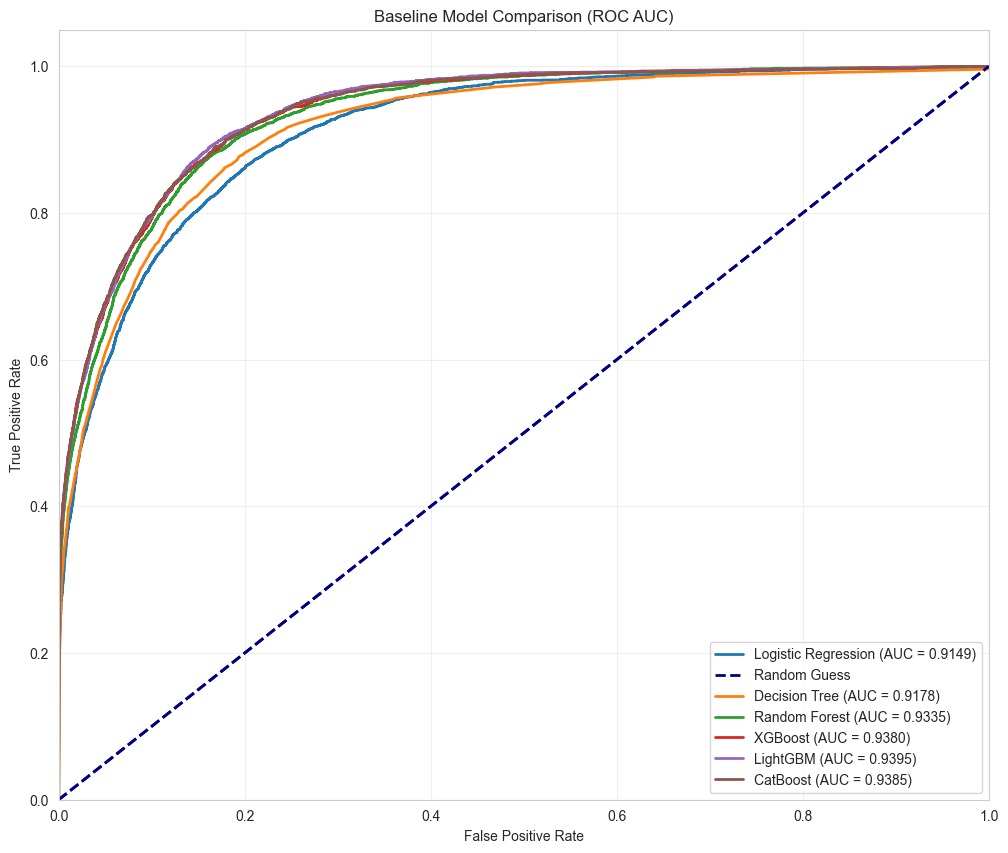


----- Baseline Models -----
LightGBM: 0.93950
CatBoost: 0.93849
XGBoost: 0.93797
Random Forest: 0.93350
Decision Tree: 0.91776
Logistic Regression: 0.91488


In [86]:
plt.figure(figsize=(12, 10))
ax = plt.gca()

results = {}

for name, model in baseline_models:
    score, trained_pipe = train_and_evaluate(
        classifier=model,
        preprocessor=preprocessing_pipeline,
        X_train=X_train, y_train=y_train,
        X_valid=X_valid, y_valid=y_valid,
        model_name=name,
        ax=ax
    )
    results[name] = score

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.title('Baseline Model Comparison (ROC AUC)')
plt.show()

print("\n----- Baseline Models -----")
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
for name, score in sorted_results:
    print(f"{name}: {score:.5f}")

#### D. Submit

In [91]:
def blend_preds(
    classifiers: list[tuple[str, BaseEstimator]],
    preprocessor: ColumnTransformer,
    X_train: Union[pd.DataFrame, np.ndarray],
    y_train: Union[pd.Series, np.ndarray],
    X_test: Union[pd.DataFrame, np.ndarray],
    submission_df: pd.DataFrame,
    weights: Optional[list[float]] = None,
    output_path: str = "submission.csv",
    target: str = "prediction"
) -> pd.DataFrame:
    """
    Trains multiple models on the full dataset, blends their predictions, and saves to CSV.

    Args:
        classifiers: List of (name, model_instance) tuples.
        preprocessor: The ColumnTransformer instance.
        X_train, y_train: The FULL training features and target.
        X_test: The test dataframe (features only).
        submission_df: The sample_submission dataframe (to get IDs).
        weights: Optional list of weights for blending (e.g. [0.4, 0.3, 0.3]). 
                 Defaults to equal weighting.
        output_path: Filename for the output CSV.

    Returns:
        pd.DataFrame: The final submission dataframe.
    """
    blended_probs = np.zeros(len(X_test))
    
    if weights is None:
        weights = [1.0 / len(classifiers)] * len(classifiers)
    
    total_weight = sum(weights)
    weights = [w / total_weight for w in weights]
    
    for i, (name, clf) in enumerate(classifiers):
        
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", clf)
        ])
        
        pipe.fit(X_train, y_train)
        
        probs = pipe.predict_proba(X_test)[:, 1]
        
        weight = weights[i]
        blended_probs += (probs * weight)

    final_sub = submission_df.copy()
    final_sub[target] = blended_probs
    
    final_sub.to_csv(output_path, index=True)
    
    return final_sub

In [92]:
# Get fresh data
train = pd.read_csv(CFG.TRAIN_PATH)
test = pd.read_csv(CFG.TEST_PATH)
sample = pd.read_csv(CFG.SAMPLE_SUB_PATH)
social_graph = pd.read_csv(CFG.SOCIAL_GRAPH_PATH)

# Prepare the target
train[CFG.TARGET] = train[CFG.TARGET].fillna(0).astype(int)

# Remove outliers immediately
train = train[train["feature_015"] >= 0].reset_index(drop=True)

X_full = train.drop(columns=[CFG.TARGET, "high_conf_clean"])
y_full = train[CFG.TARGET]

# Using the same hyperparameters
top_models = [
    ("CatBoost", fix_catboost(CatBoostClassifier(n_estimators=100, depth=6, verbose=0, random_state=42))),
    ("XGBoost", XGBClassifier(n_estimators=100, max_depth=6, eval_metric='logloss', n_jobs=-1, random_state=42)),
    ("LightGBM", LGBMClassifier(n_estimators=100, max_depth=10, verbosity=-1, n_jobs=-1, random_state=42))
]


submission = blend_preds(
    classifiers=top_models,
    preprocessor=preprocessing_pipeline,
    X_train=X_full,
    y_train=y_full,
    X_test=test,
    submission_df=sample,
    weights=None,
    output_path="submission.csv"
)

print(submission.head())

          user_hash  prediction
0  33915f8c9f1ff891    0.580761
1  9b6216bf06fcf724    0.351122
2  7d8c9db1fc22bb6b    0.364371
3  aa231cad06c66ab1    0.097373
4  bc41e60a4ff49aa5    0.516079
